In [43]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier

In [44]:
df = pd.read_csv("../../Datasets/computer_buys.csv", delimiter=";", encoding="unicode_escape")
df.head()

,age,income,student,credit_rating,buys_computer
0,<=30,high,no,fair,no
1,<=30,high,no,excellent,no
2,31to40,high,no,fair,yes
3,>40,medium,no,fair,yes
4,>40,low,yes,fair,yes


## Visualisasi Data

In [45]:
jumdata = len(df.index)
print(jumdata)
df['buys_computer'].value_counts()

14


buys_computer
yes    9
no     5
Name: count, dtype: int64

<Axes: xlabel='buys_computer'>

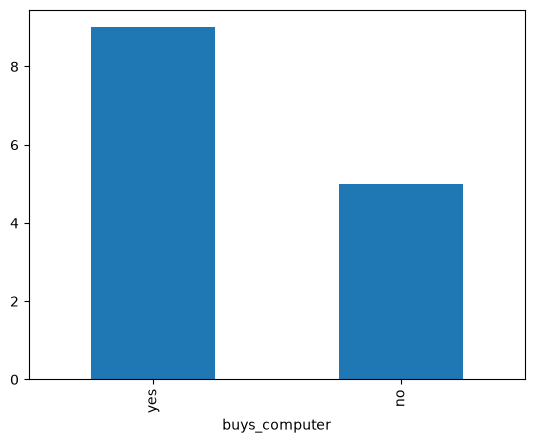

In [46]:
df['buys_computer'].value_counts().plot(kind = 'bar')

## Data Preprocessing

### Selanjutnya, kita format dataset, yaitu bentuk feature sets (kumpulan atribut), kita bentuk variabel X:

In [47]:
df.columns

Index(['age', 'income', 'student', 'credit_rating', 'buys_computer'], dtype='str')

### Untuk menggunakan library scikit-learn library, kita harus convert format data frame-nya Panda, ke array Numpy 

In [48]:
X = df[['age', 'income', 'student', 'credit_rating']].values  #.astype(float)
X[0:5]

array([['<=30', 'high', 'no', 'fair'],
       ['<=30', 'high', 'no', 'excellent'],
       ['31to40', 'high', 'no', 'fair'],
       ['>40', 'medium', 'no', 'fair'],
       ['>40', 'low', 'yes', 'fair']], dtype=object)

### Definisikan Labelnya juga (Y):

In [49]:
y = df['buys_computer'].values
y[0:5]

<StringArray>
['no', 'no', 'yes', 'yes', 'yes']
Length: 5, dtype: str

### Metode Decision Tree pada Sklearn hanya menerima jenis data numerik, sehingga kita harus mengubah data kategorikal menjadi numerik terlebih dahulu

In [50]:
from sklearn import preprocessing
le_age = preprocessing.LabelEncoder()
le_age.fit(['<=30','31to40','>40'])
X[:,0] = le_age.transform(X[:,0])

#'income', 'student', 'credit_rating'
le_income = preprocessing.LabelEncoder()
le_income.fit(['high','medium','low'])
X[:,1] = le_income.transform(X[:,1])

le_student = preprocessing.LabelEncoder()
le_student.fit(['yes','no'])
X[:,2] = le_student.transform(X[:,2])

le_credit = preprocessing.LabelEncoder()
le_credit.fit(['fair','excellent'])
X[:,3] = le_credit.transform(X[:,3])

X

array([[1, 0, 0, 1],
       [1, 0, 0, 0],
       [0, 0, 0, 1],
       [2, 2, 0, 1],
       [2, 1, 1, 1],
       [2, 1, 1, 0],
       [0, 1, 1, 0],
       [1, 2, 0, 1],
       [1, 1, 1, 1],
       [2, 2, 1, 1],
       [1, 2, 1, 0],
       [0, 2, 0, 0],
       [0, 0, 1, 1],
       [2, 2, 0, 0]], dtype=object)

### Membagi dataset menjadi data training dan testing

In [51]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=4)
print ('Train set:', X_train.shape,  y_train.shape)
print ('Test set:', X_test.shape,  y_test.shape)

Train set: (11, 4) (11,)
Test set: (3, 4) (3,)


## Decision Tree

### Training

In [52]:
mTree = DecisionTreeClassifier(criterion="entropy")
#mTree

mTree.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsam

### Prediksi

In [53]:
predTree = mTree.predict(X_test)
print(predTree[0:2])
print(y_test[0:2])

['yes' 'no']
<StringArray>
['yes', 'yes']
Length: 2, dtype: str


## Perhitungan Akurasi

### Pada klasifikasi, nilai akurasi klasifikasi secara sederhana dapat dihitung dengan memperbandingkan kelas hasil prediksi algoritma dengan kelas sebenarnya / actual class.

In [54]:
from sklearn import metrics
print("Test set Accuracy: ", metrics.accuracy_score(predTree, y_test))

Test set Accuracy:  0.6666666666666666


## Visualisasi Decision Tree

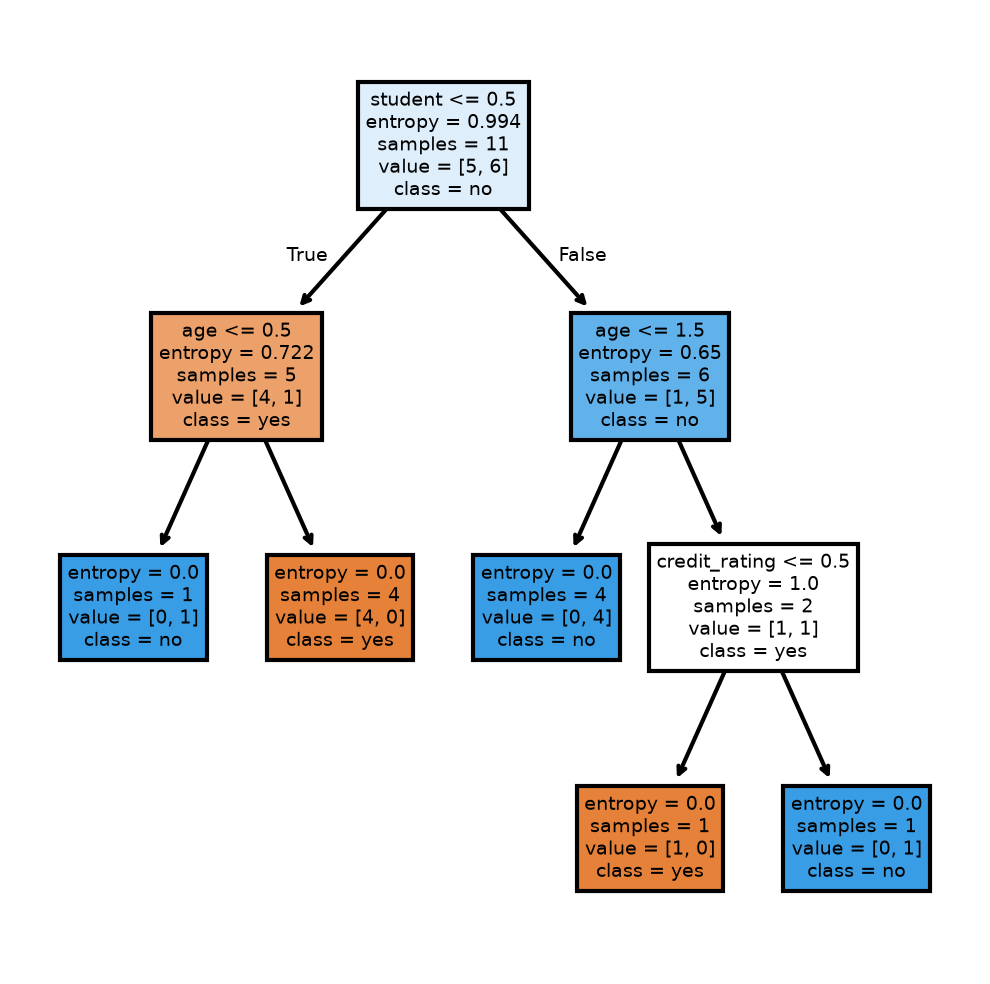

In [55]:
from sklearn import tree

fn=['age','income','student','credit_rating']
cn=['yes', 'no']
fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (4,4), dpi=300)
tree.plot_tree(mTree,
               feature_names = fn, 
               class_names=cn,
               filled = True);